# GAPS ETF Pipeline
**순서:** 설정 → (선택) 데이터 수집 → 전처리 → 학습 → 예측 → 포트폴리오

> **매주 실행 시:** Cell 0(설정) 확인 후 Section 5(전처리)부터 실행  
> **최초 실행 시:** 전체 순서대로 실행


## 0. 설정 ← 여기만 수정

In [1]:
import os, sys
from pathlib import Path
from datetime import datetime, timedelta

# ★ 이 노트북 파일이 GAPS_Pipeline 폴더 안에 있다고 가정
# 다른 위치에 있으면 아래 PIPELINE_ROOT 를 직접 지정하세요
PIPELINE_ROOT = Path(r"/Users/jio/Desktop/GAPS_Pipeline_final/GAPS_Pipeline_notebook")
sys.path.insert(0, str(PIPELINE_ROOT))
sys.path.insert(0, str(PIPELINE_ROOT / "src_tft"))

# ── API 키 ──────────────────────────────────────────────────
BOK_API_KEY = "515TAITK5CQWK55DMMRF"   # 한국은행 ECOS
NYT_API_KEY = "YOUR_NYT_API_KEY"         # NYT (IP 차단 시 사용)

# ── 날짜 설정 ───────────────────────────────────────────────
PRED_DATE   = "2026-05-29"   # ★ 예측 기준일 (매주 월요일로 변경)
TRAIN_END   = "2025-12-30"   # 학습 종료일
VAL_START   = "2026-01-01"   # 검증 시작일

# ── 재학습 여부 ───────────────────────────────────────오늘 6월 1일 워──────
DO_RETRAIN  = False   # True: 학습 후 예측 / False: 기존 체크포인트로 예측만

# ── 크롤링 기간 (매주 직전 7일) ─────────────────────────────
NEWS_END   = datetime.today().strftime("%Y-%m-%d")
NEWS_START = (datetime.today() - timedelta(days=7)).strftime("%Y-%m-%d")

# ── 경로 ────────────────────────────────────────────────────
DATA_DIR    = PIPELINE_ROOT / "data"
FINAL_CSV   = DATA_DIR / "final_dataset.csv"
NEWS_RAW    = DATA_DIR / "news" / "raw"
NEWS_MERGED = DATA_DIR / "news" / "merged"
SRC_TFT     = PIPELINE_ROOT / "src_tft"

for d in [NEWS_RAW, NEWS_MERGED, DATA_DIR / "outputs" / "logs"]:
    d.mkdir(parents=True, exist_ok=True)

# ── config 패치 (이미 있는 config.py 변수들 오버라이드) ──────
import config as cfg
cfg.BOK_API_KEY  = BOK_API_KEY
cfg.NYT_API_KEY  = NYT_API_KEY
cfg.FINAL_DATASET= FINAL_CSV
cfg.RAW_DIR      = NEWS_RAW
cfg.MERGED_DIR   = NEWS_MERGED

import src_tft.config as tft_cfg
tft_cfg.TRAIN_END_DATE = TRAIN_END
tft_cfg.VAL_START_DATE = VAL_START
tft_cfg.PROCESSED_DATA_PATH = str(SRC_TFT / "outputs" / "data" / "final_dataset_preprocessed.csv")
tft_cfg.CHECKPOINT_DIR = SRC_TFT / "outputs" / "checkpoints"
tft_cfg.PORTFOLIO_RESULT_DIR = SRC_TFT / "outputs" / "portfolio"

print("✅ 설정 완료")
print(f"   PIPELINE_ROOT : {PIPELINE_ROOT}")
print(f"   PRED_DATE     : {PRED_DATE}")
print(f"   DO_RETRAIN    : {DO_RETRAIN}")
print(f"   FINAL_CSV     : {FINAL_CSV}  (존재: {FINAL_CSV.exists()})")


✅ 설정 완료
   PIPELINE_ROOT : /Users/jio/Desktop/GAPS_Pipeline_final/GAPS_Pipeline_notebook
   PRED_DATE     : 2026-05-29
   DO_RETRAIN    : False
   FINAL_CSV     : /Users/jio/Desktop/GAPS_Pipeline_final/GAPS_Pipeline_notebook/data/final_dataset.csv  (존재: True)


## 1. 패키지 설치 (최초 1회만 실행)

In [2]:
# 최초 1회만 실행하세요
!pip install pykrx yfinance selenium webdriver-manager pandas numpy
!pip install torch pytorch-forecasting pytorch-lightning
!pip install transformers accelerate
!pip install streamlit plotly  # 대시보드용 (선택)
print("이미 설치되어 있으면 위 주석 해제 후 실행하세요.")


이미 설치되어 있으면 위 주석 해제 후 실행하세요.


ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


## 2. 가격 + 거시지표 수집 (주간 증분)
> 매주 실행. 직전 10일치만 수집 후 기존 CSV에 append.  
> **이번 주는 SKIP** — 5월 29일 데이터까지 이미 있으므로 Section 5로 바로 이동.


In [ ]:
# ── ETF 리스트 (config.py TICKER_ASSET_MAP 기반) ────────────
etf_rows = []
for ticker, (asset_class, category2, cap) in cfg.TICKER_ASSET_MAP.items() if hasattr(cfg, 'TICKER_ASSET_MAP') else tft_cfg.TICKER_ASSET_MAP.items():
    code_num = ticker.replace("A","")
    etf_rows.append({"code": code_num, "ticker": ticker, "name": "", "sector": "", "aum": 0})

import pandas as pd
etf_df = pd.DataFrame(etf_rows)

# ── 가격 수집 ────────────────────────────────────────────────
from collectors.collect_macro import collect_prices, collect_macro

# 증분 수집 (최근 10일)
print("=== 가격 수집 ===")
price_df = collect_prices(etf_df, incremental=True)
print(f"완료: {price_df['code'].nunique()}종목, {len(price_df):,}행")

print("\n=== 거시지표 수집 ===")
macro_df = collect_macro(incremental=True)
print("완료")


## 3. 뉴스 크롤링 (주간 증분)
> Chrome 창이 뜹니다. 닫지 마세요.  
> **이번 주는 SKIP** — 2026년 1~5월 크롤링 데이터 이미 있음.


In [ ]:
from collectors.crawl_mk  import crawl_mk
from collectors.crawl_nyt import crawl_nyt

print(f"크롤링 기간: {NEWS_START} ~ {NEWS_END}")

# 매일경제
print("\n=== 매일경제 크롤링 ===")
crawl_mk(start=NEWS_START, end=NEWS_END)

# NYT
print("\n=== NYT 크롤링 ===")
crawl_nyt(start=NEWS_START, end=NEWS_END)


## 4. 감성 점수 산출
> KR-FinBERT (매경) + FinBERT (NYT) → 날짜×섹터 감성 집계  
> GPU 있으면 자동으로 CUDA 사용.  
> **이번 주는 SKIP** — 이미 완성된 데이터셋 사용.


In [ ]:
from processors.sentiment_score import score_all_sectors

print("=== 감성 점수 산출 ===")
sent_df = score_all_sectors()
print(f"완료: {len(sent_df)}행")
print(sent_df.head())


## 4.5 데이터셋 갱신 (final_dataset.csv append)
> 가격 + 거시 + 감성 → final_dataset.csv 뒤에 이어 붙이기  
> **이번 주는 SKIP**


In [ ]:
from processors.build_dataset import append_new_data

print("=== 데이터셋 갱신 ===")
final_df = append_new_data()
print(f"완료: {final_df['ticker'].nunique()}종목, {len(final_df):,}행")
print(f"기간: {final_df['date'].min()} ~ {final_df['date'].max()}")


## 5. TFT 전처리 ← 매주 실행
> `final_dataset.csv` → `final_dataset_preprocessed.csv`  
> log1p 변환, sector z-score, macro 표준화, scaler 저장


In [2]:
import subprocess, sys

preprocess_path = str(SRC_TFT / "data" / "preprocess.py")
result = subprocess.run(
    [sys.executable, preprocess_path],
    cwd=str(SRC_TFT),
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print("❌ 오류:")
    print(result.stderr)
else:
    print("✅ 전처리 완료")


Loading data...
  Shape: (254919, 21)
Applying log1p...
  Train rows: 236307, Val rows: 18612
Fitting sector z-score stats (train only)...
Fitting macro StandardScaler (train only)...
Preprocessed data saved to /Users/jio/Desktop/GAPS_Pipeline_final/GAPS_Pipeline_notebook/src_tft/outputs/data/final_dataset_preprocessed.csv
Scalers saved to /Users/jio/Desktop/GAPS_Pipeline_final/GAPS_Pipeline_notebook/src_tft/outputs/scalers

── Sanity Check ──
  Columns: ['date', 'ticker', 'name', 'end', 'target_5d', 'sector', 'category1', 'category2', 'usd_krw', 'vix_close', 'us_10y', 'kr_10y', 'rate_spread', 'time_idx', 'domestic_mean', 'domestic_std', 'global_mean', 'global_std', 'AUM_log', 'domestic_count_log', 'global_count_log']
  NaN counts:
target_5d    940
dtype: int64
  Scaler fit 기준 max date: 2025-12-30
  Val date range: 2026-01-02 00:00:00 ~ 2026-05-29 00:00:00

✅ 전처리 완료


## 6. TFT 모델 학습
> `DO_RETRAIN = False` 이면 이 셀 스킵하고 Section 7로  
> GPU 있으면 자동 사용 (accelerator='auto')  
> EarlyStopping patience=5, 최대 50 epoch


In [4]:
if not DO_RETRAIN:
    print("DO_RETRAIN=False → 학습 스킵, Section 7로 이동")
else:
    import os
    os.chdir(str(SRC_TFT))      # src_tft 폴더로 이동 (상대경로 import용)
    sys.path.insert(0, str(SRC_TFT))

    from data.dataset import make_datasets
    from model.tft    import build_model, build_trainer

    print("=== 데이터셋 로드 ===")
    train_ds, val_ds, train_loader, val_loader = make_datasets()
    print(f"  Train samples : {len(train_ds):,}")
    print(f"  Val   samples : {len(val_ds):,}")

    print("\n=== 모델 빌드 ===")
    model = build_model(train_ds)
    print(f"  파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

    print("\n=== 학습 시작 (GPU 있으면 자동 사용) ===")
    trainer = build_trainer(
        max_epochs   = tft_cfg.MAX_EPOCHS,
        gradient_clip_val = tft_cfg.gradient_clip_val,
    )
    trainer.fit(model,
                train_dataloaders=train_loader,
                val_dataloaders=val_loader)

    best_ckpt = trainer.checkpoint_callback.best_model_path
    print(f"\n✅ 학습 완료")
    print(f"   Best checkpoint : {best_ckpt}")
    print(f"   Best val_loss   : {trainer.checkpoint_callback.best_model_score:.6f}")

    os.chdir(str(PIPELINE_ROOT))   # 원복


C:\Users\jo977\anaconda3\envs\ml_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0601 02:26:56.952000 36052 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


=== 데이터셋 로드 ===
  Train date range : 2019-01-02 ~ 2025-12-30
  Val start date   : 2026-01-02
  val_min_idx      : 129
  Train rows       : 236307
  Val samples      : 228975
  Train samples : 224,275
  Val   samples : 228,975

=== 모델 빌드 ===


C:\Users\jo977\anaconda3\envs\ml_env\lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 5070') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
C:\Users\jo977\anaconda3\envs\ml_env\lib\site-packag

  파라미터 수: 377,782

=== 학습 시작 (GPU 있으면 자동 사용) ===


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │  5.7 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  1.1 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 21.3 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  101 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 42.0 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  8.3 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    128 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    195 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

...

C:\Users\jo977\anaconda3\envs\ml_env\lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

C:\Users\jo977\anaconda3\envs\ml_env\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: 
The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

C:\Users\jo977\anaconda3\envs\ml_env\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: 
The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

Metric val_loss improved. New best score: 0.012
Metric val_loss improved by 0.001 >= min_delta = 1e-05. New best score: 0.011
Metric val_loss improved by 0.001 >= min_delta = 1e-05. New best score: 0.010
Metric val_loss improved by 0.001 >= min_delta = 1e-05. New best score: 0.009
Metric val_loss improved by 0.000 >= min_delta = 1e-05. New best score: 0.009
Metric val_loss improved by 0.000 >= min_delta = 1e-05. New best score: 0.009
Metric val_loss improved by 0.000 >= min_delta = 1e-05. New best score: 0.008
Metric val_loss improved by 0.000 >= min_delta = 1e-05. New best score: 0.008
Metric val_loss improved by 0.000 >= min_delta = 1e-05. New best score: 0.008
Metric val_loss improved by 0.000 >= min_delta = 1e-05. New best score: 0.008
Metric val_loss improved by 0.000 >= min_delta = 1e-05. New best score: 0.008
Metric val_loss improved by 0.000 >= min_delta = 1e-05. New best score: 0.007
Metric val_loss improved by 0.000 >= min_delta = 1e-05. New best score: 0.007
Metric val_loss 


✅ 학습 완료
   Best checkpoint : C:\Users\jo977\Desktop\임지오\공모전\gaps\GAPS_Pipeline_final\GAPS_Pipeline_notebook\src_tft\outputs\checkpoints\v1\tft-v1-epoch=49-val_loss=0.0061.ckpt
   Best val_loss   : 0.006053


## 7. TFT 예측 + 포트폴리오 ← 매주 실행
> 체크포인트 자동 탐색 (최신 .ckpt)  
> 결과: `src_tft/outputs/portfolio/{PRED_DATE}/`


In [13]:
import importlib
import sys

# 캐시된 모듈 강제 제거
for mod in list(sys.modules.keys()):
    if 'portfolio' in mod or 'predict' in mod:
        del sys.modules[mod]

print("캐시 클리어 완료")

캐시 클리어 완료


In [4]:
!pip install torch torchmetrics pytorch-forecasting pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 3.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 3.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 3.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 3.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [pytorch-forecasting]torch-forecasting]


In [3]:
import os
os.chdir(str(SRC_TFT))
sys.path.insert(0, str(SRC_TFT))

from predict import run_inference, build_portfolio
from pathlib import Path

# 체크포인트 자동 탐색
ckpt_dir = SRC_TFT / "outputs" / "checkpoints"
ckpts    = []
for p in ckpt_dir.rglob("*.ckpt"):
    ckpts.append(p)
ckpts.sort(key=lambda p: p.stat().st_mtime)

if not ckpts:
    print("❌ 체크포인트 없음. Section 6(학습)을 먼저 실행하세요.")
else:
    best_ckpt = ckpts[-1]
    print(f"체크포인트 : {best_ckpt.name}")
    print(f"예측 기준일: {PRED_DATE}")
    

    print("\n=== 추론 ===")
    pred_df = run_inference(best_ckpt, pred_date=PRED_DATE)

    print("\n=== 포트폴리오 구성 ===")
    portfolio = build_portfolio(pred_df, pred_date=PRED_DATE)

    out_dir = SRC_TFT / "outputs" / "portfolio" / PRED_DATE
    print(f"\n✅ 완료 → {out_dir}")

    os.chdir(str(PIPELINE_ROOT))


체크포인트 : tft-v1-epoch=49-val_loss=0.0061.ckpt
예측 기준일: 2026-05-29

=== 추론 ===
[load] checkpoint: /Users/jio/Desktop/GAPS_Pipeline_final/GAPS_Pipeline_notebook/src_tft/outputs/checkpoints/v1/tft-v1-epoch=49-val_loss=0.0061.ckpt


/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.


  Train date range : 2019-01-02 ~ 2025-12-30
  Val start date   : 2026-01-02
  val_min_idx      : 129
  Train rows       : 236307
  Val samples      : 228975
[inference] 예측 기준일: 2026-05-29
[inference] pred_date=2026-05-29, valid tickers=188


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/opt/anaconda3/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automat

         pred_q10    pred_q50    pred_q90
count  188.000000  188.000000  188.000000
mean    -0.004055    0.008925    0.022629
std      0.021757    0.022600    0.026607
min     -0.090959   -0.047784   -0.019254
25%     -0.017567   -0.000750    0.004889
50%     -0.000487    0.005759    0.019785
75%      0.006512    0.016392    0.031925
max      0.065182    0.092893    0.123301
[inference] 예측 완료: 188건 / valid tickers: 188개
                  name  pred_q10  pred_q50  pred_q90
0  SOL 중단기회사채(A-이상)액티브  0.000309  0.001393  0.002593
1      RISE 단기특수은행채액티브  0.000097  0.000562  0.001056
2            KODEX 200  0.010094  0.015312  0.022192
3            KODEX 반도체  0.036566  0.061278  0.089832
4             KODEX 은행  0.014777  0.025662  0.038355
5            KODEX 자동차 -0.029981 -0.012279  0.007673
6           KODEX 차이나H  0.021238  0.035972  0.052513
7     KODEX 일본TOPIX100  0.006221  0.021528  0.037588
8            TIGER 200  0.010201  0.015495  0.022476
9           KODEX 삼성그룹  0.034257  0.039870  0.

## 8. 결과 확인

In [4]:
import pandas as pd
from pathlib import Path

out_dir = SRC_TFT / "outputs" / "portfolio" / PRED_DATE

print(f"=== 안정형 포트폴리오 ({PRED_DATE}) ===")
cons = pd.read_csv(out_dir / "portfolio_conservative.csv")
print(cons[["name","sub_asset","weight","signal_return"]].to_string(index=False))
print(f"\n  비중합계: {cons['weight'].sum():.4f}")

print(f"\n=== 수익추구형 포트폴리오 ({PRED_DATE}) ===")
agg  = pd.read_csv(out_dir / "portfolio_aggressive.csv")
print(agg[["name","sub_asset","weight","signal_return"]].to_string(index=False))
print(f"\n  비중합계: {agg['weight'].sum():.4f}")


=== 안정형 포트폴리오 (2026-05-29) ===
                name   sub_asset   weight  signal_return
          KODEX 삼성그룹     국내주식_섹터 0.034910       0.039870
        TIGER 200 IT     국내주식_섹터 0.030933       0.055632
      KODEX 200IT TR     국내주식_섹터 0.028821       0.060091
        TIGER 2차전지테마     국내주식_섹터 0.028149       0.092893
        KODEX 2차전지산업     국내주식_섹터 0.027188       0.085799
 KODEX MSCI Korea TR     국내주식_지수 0.127834       0.019037
RISE 중국MSCI China(H)     해외주식_지수 0.122166       0.060470
       KODEX 머니마켓액티브 금리연계형/초단기채권 0.200000       0.000928
        RISE 머니마켓액티브 금리연계형/초단기채권 0.200000       0.000804
TIGER 단기선진하이일드(합성 H)    해외채권_회사채 0.200000       0.007111

  비중합계: 1.0000

=== 수익추구형 포트폴리오 (2026-05-29) ===
              name sub_asset  weight  signal_return
      TIGER 2차전지테마   국내주식_섹터    0.15       0.092893
     KODEX 차이나항셍테크   해외주식_지수    0.20       0.061587
     TIGER 차이나항셍테크   해외주식_지수    0.10       0.056651
      KODEX 은선물(H)  FX 및 원자재    0.20       0.043121
 KODEX 미국AI전력핵심인프라   해외주식_섹터    

In [5]:
print(f"=== 안정형 포트폴리오 ({PRED_DATE}) ===")
cons = pd.read_csv(out_dir / "portfolio_conservative.csv")
cons_active = cons[cons['weight'] > 0.001]
print(cons_active[["name","sub_asset","weight","signal_return"]].to_string(index=False))
print(f"\n  비중합계: {cons_active['weight'].sum():.4f}")
print(f"  편입 종목 수: {len(cons_active)}")

print(f"\n=== 수익추구형 포트폴리오 ({PRED_DATE}) ===")
agg = pd.read_csv(out_dir / "portfolio_aggressive.csv")
agg_active = agg[agg['weight'] > 0.001]
print(agg_active[["name","sub_asset","weight","signal_return"]].to_string(index=False))
print(f"\n  비중합계: {agg_active['weight'].sum():.4f}")
print(f"  편입 종목 수: {len(agg_active)}")

=== 안정형 포트폴리오 (2026-05-29) ===
                name   sub_asset   weight  signal_return
          KODEX 삼성그룹     국내주식_섹터 0.034910       0.039870
        TIGER 200 IT     국내주식_섹터 0.030933       0.055632
      KODEX 200IT TR     국내주식_섹터 0.028821       0.060091
        TIGER 2차전지테마     국내주식_섹터 0.028149       0.092893
        KODEX 2차전지산업     국내주식_섹터 0.027188       0.085799
 KODEX MSCI Korea TR     국내주식_지수 0.127834       0.019037
RISE 중국MSCI China(H)     해외주식_지수 0.122166       0.060470
       KODEX 머니마켓액티브 금리연계형/초단기채권 0.200000       0.000928
        RISE 머니마켓액티브 금리연계형/초단기채권 0.200000       0.000804
TIGER 단기선진하이일드(합성 H)    해외채권_회사채 0.200000       0.007111

  비중합계: 1.0000
  편입 종목 수: 10

=== 수익추구형 포트폴리오 (2026-05-29) ===
              name sub_asset  weight  signal_return
      TIGER 2차전지테마   국내주식_섹터    0.15       0.092893
     KODEX 차이나항셍테크   해외주식_지수    0.20       0.061587
     TIGER 차이나항셍테크   해외주식_지수    0.10       0.056651
      KODEX 은선물(H)  FX 및 원자재    0.20       0.043121
 KODEX 미국AI전력핵심인프라

## 8.5 포트폴리오 시각화 (선택)

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
/var/folders/2q/fl_87nc16sb4w5m2s1lgp6mw0000gn/T/ipykernel_57010/2850505617.py:18: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2q/fl_87nc16sb4w5m2s1lgp6mw0000gn/T/ipykernel_57010/2850505617.py:18: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Font family 'Malgun Gothic' not found.
/var/folders/2q/fl_87nc16sb4w5m2s1

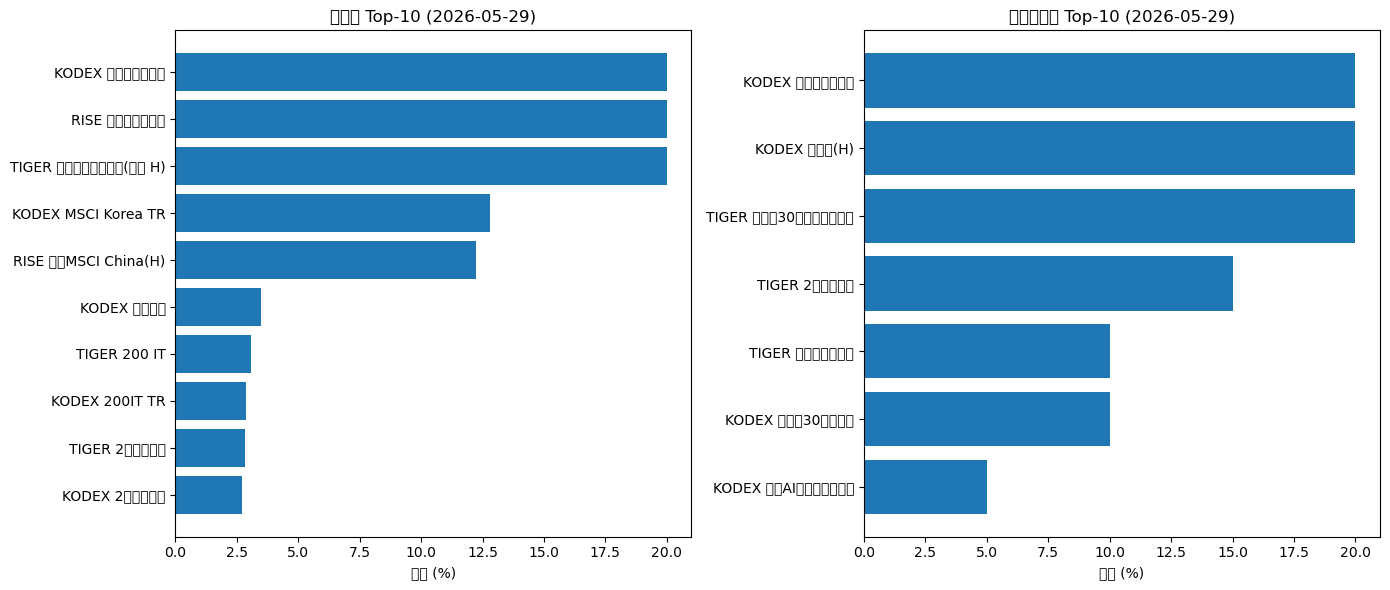

In [6]:
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'   # Windows 한글
# Mac: 'AppleGothic'  /  Linux: 'NanumGothic'
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, df, title in [(axes[0], cons, "안정형"), (axes[1], agg, "수익추구형")]:
    if df.empty:
        ax.set_title(f"{title} — 편입 없음")
        continue
    top = df.nlargest(10, "weight")
    ax.barh(top["name"], top["weight"] * 100)
    ax.set_xlabel("비중 (%)")
    ax.set_title(f"{title} Top-10 ({PRED_DATE})")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()


## 9. Streamlit 대시보드 (선택)
> 별도 터미널에서 실행하거나 아래 셀 주석 해제 후 실행, 별도 터미널 추천


In [19]:
!pip install streamlit plotly -q

In [20]:
import subprocess, sys
subprocess.Popen([sys.executable, "-m", "streamlit", "run", 
                  str(PIPELINE_ROOT / "dashboard" / "app.py")])

import time
time.sleep(3)
print("브라우저에서 열기 → http://localhost:8501")

브라우저에서 열기 → http://localhost:8501


In [17]:
# 아래 주석 해제 후 실행 (새 터미널 열기를 권장)
import subprocess
subprocess.Popen(["streamlit", "run", str(PIPELINE_ROOT / "dashboard" / "app.py")])
print("브라우저에서 http://localhost:8501 접속")
print("터미널에서 실행: streamlit run dashboard/app.py")


브라우저에서 http://localhost:8501 접속
터미널에서 실행: streamlit run dashboard/app.py
